# Transformer 번역기 만들기 (Node 10)   by 김민수

<Review>

[ Review ]

- LMS의 코드에 너무 많은 오류들이 존재하여 이 오류들을 하나씩 수정하며 번역 성능을 개선하는데 많은 시간이 소요되었다.
- 특히 Attention 모듈에 Masking 관련한 코드 오류가(mask == 0, -1e9) 존재하여 정상 토큰을 모두 가려버리는 바람에 지속적으로 학습 불가 상황에 빠졌었다. 
- 그 외 Cleaning, LR Scheduler, Time step, Evaluate 모듈에도 여러 오류들이 발견되었다.
- 중간중간 노드 접속 불안정으로 인해 작업한 내용이 소실되는 불운도 겪었다... T T


- 학습 데이터 셋 크기가 크지 않아서 과적합이 유발되는 모습이 반복 관찰되어 과적합 방지를 위한 여러 장치를 추가하였다.
- 예를 들어, drop out 값 증대, FFNN 차원수 축소,  batch size와 epoch 수 감수 등의 Parameter 조정을 진행하였으며,
- Train_step에 Gradient Clipping, Epoch 루프에 Early stopping 추가 및 Loss 함수에 Label Smoothing, Scheduler에 warmup_steps 설정을 병행하였다.

- 학습 epoch 진행에 따라 Loss 값 크게 감소하는 것 확인: epoch #1: 6413.36 => epoch #15: 77.33
- 그러나 번역 결과는 기대수준에 미치지 못하였음: the the the 와 같이 특정 단어의 반복...
  
- 이에 소규모 데이터에 최적화하기 위해 d_model 차원 수를 512 => 256 으로 변경하여 2차 학습을 진행하였음.
- 2차 학습 시에도 epoch 진행에 따라 Loss 값 감소: epoch #1: 1845.93 => epoch #15: 17.81
- 번역 결과는 1차 학습 결과 보다는 조금 개선되었으나, 여전히 정상 번역 수준에 도달하지 못하였음.
- 특히, epoch #10 부터 Loss 값이 21 부근에서 감소 폭이 눈에 띄게 둔화되어 epoch #15 때에도 다소 높은 값을 유지.
- 차원 축소로 인해 parameter 수량이 감소함에 따라 학습시간이 크게 단축되었음: epoch당 3분8초 => 1분47초  

In [2]:
!pip install sentencepiece

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(torch.__version__)

2.7.1+cu118


1. 데이터 전처리 : 정제

In [4]:
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir+"/korean-english-park.train.ko"
eng_path = data_dir+"/korean-english-park.train.en"

# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)

    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)


def preprocess_sentence(sentence):

  sentence = sentence.lower()                               # 소문자 변환 
  sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)  # 알파벳, 한글, 문장부호 외 제거 
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)        # 문장부호 양옆에 공백 추가
  sentence = re.sub(r'[" "]+', " ", sentence)              # 문장 앞뒤의 공백 제거 

  return sentence


2. 데이터 전처리 : Tokenize 

In [6]:
# Sentencepiece를 활용하여 학습한 tokenizer를 생성.

import sentencepiece as spm

def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
      for row in corpus: f.write(str(row) + '\n')

    spm.SentencePieceTrainer.Train(
      '--input=%s --model_prefix=%s --vocab_size=%d ' % (file, model, vocab_size) + \
      '--pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d' % (pad_id, bos_id, eos_id, unk_id)
    )    # LMS 코드 오류 수정

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")

    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

ko_tokenizer.set_encode_extra_options("bos:eos")       # 코드 추가
en_tokenizer.set_encode_extra_options("bos:eos")


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
 

True

In [7]:
from tqdm.notebook import tqdm     # 진행 과정 시각화 Tool

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus), "데이터 개수가 다릅니다"

# 토큰의 길이가 50 이하인 문장만 남기기.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 문장 끝 패딩 처리하여 학습용 데이터 완성.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(enc_train.shape, dec_train.shape)
print(src_corpus[:3])
print(enc_train[:3])


  0%|          | 0/78968 [00:00<?, ?it/s]

torch.Size([71762, 50]) torch.Size([71762, 50])
[tensor([    1, 16099,     7,  7305,    11,    20,   316,  9262,   295,   674,
          470,   141,  3591,     9,  5594,    64, 11697,  3811, 12610,  4642,
            5, 13732,  1723,   165,     4,     2]), tensor([    1,  6764,  1112,  1111,     6,  2618,   195,  6608,    10, 14600,
         3312,    93,   171,   174,   898,    51, 16453,    10, 13935,     4,
            2]), tensor([    1,   241,  2921,     6, 13710,    18,   321,  1065,    10,  5032,
          795,    34, 10595,  8690,   524,    89,   256,  1540,    10,  2933,
          338,    17,   138,    24,     4,     2])]
tensor([[    1, 16099,     7,  7305,    11,    20,   316,  9262,   295,   674,
           470,   141,  3591,     9,  5594,    64, 11697,  3811, 12610,  4642,
             5, 13732,  1723,   165,     4,     2,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,   

3. Model 설계 : Positional Encoding, Multi Head Attention, Feed Forward Neural Network

$$
PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{hidn}}}\right), \qquad
PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{hidn}}}\right)
$$
$$\frac{1}{10000^{2i/d}} = \exp\!\bigl(\log(10000^{-2i/d})\bigr) = \exp\!\bigl(2i \cdot (-\log 10000 / d)\bigr)$$

In [8]:
# PE + MHA + FFNN

def positional_encoding(pos, d_model):
    def cal_angle(position, i):

        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))
        
        scaled_qk = QK / math.sqrt(d_k)
        # scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:                                             # mask 값이 1인 경우 큰 음수 값으로 치환하여 Attention 연산 제외
            scaled_qk = scaled_qk.masked_fill(mask == 1, float('-1e9'))  # LMS 오류 수정: 기존에는 mask == 0 

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)    # bsz = batch size
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


4. Model 설계: Encoder, Decoder, Transformer

In [9]:
# Encoder Layer + Decoder Layer

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)    # 분모에 epsilon 값 더해주기
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn


In [10]:
# Encoder + Decoder 

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []                   # Encoder 내 Self Attention 값

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []                   # Decoder 내 Self Attention 값
        dec_enc_attns = []               # Encoder-Decoder 간 Cross Attention 값

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns


In [11]:
# Transformer 

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.3, shared=True):        
         # 소규모 데이터임을 감안하여 과적합 방지 위해 drop out 값 조정: 0.2 -> 0.3
        
        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.register_buffer('pos_encoding', self.positional_encoding(pos_len, d_model))
        
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

        
        # 가중치 초기화 
        self._init_weights()     

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'emb' not in name and p.dim() > 1:
                nn.init.xavier_uniform_(p)
                

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() /d_model * -(torch.log(torch.tensor(10000.0))))

        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding
        

    def embedding(self, emb, x):
        seq_len = x.shape[1]
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device) 
        out += pos_enc

        out = self.dropout(out)
        return out

    
    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns


5. Masking 

In [12]:
def generate_padding_mask(seq):
    """ 패딩된 부분(0)을 1로 변환하여 마스크 생성 """
    mask = (seq == 0).float() * -1e9
    return mask[:, None, None, :]

def generate_causality_mask(seq_len):
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
    return mask.float()
    
# def generate_causality_mask(src_len, tgt_len):
#     """ 미래 정보를 참조하지 않도록 Causal Mask 생성 """
#     mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
#     return mask.float()

def generate_masks(src, tgt):
    """ Encoder-Decoder에서 사용할 마스크 생성 """
    enc_mask = generate_padding_mask(src).to(device)
    dec_mask = generate_padding_mask(tgt).to(device)

    dec_causality_mask = generate_causality_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(0).to(device)
                                                               # [1, 1, tgt_len, tgt_len]
    dec_mask = torch.max(dec_mask, dec_causality_mask)         # [batch, 1, tgt_len, tgt_len]
    dec_enc_mask = enc_mask                                    # [batch, 1, tgt_len, src_len]

    # dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask)
    # dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1]).unsqueeze(0).unsqueeze(0).to(device)

    # dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    # dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))
    # dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    # dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))

    return enc_mask, dec_enc_mask, dec_mask


transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=1024,                       # 과적합 방지 위해 FFNN 차원 축소: 2048 -> 1024
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=True
)


6. Optimizer 및 Learning Rate Scheduler, Loss Function

In [13]:

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]


optimizer = torch.optim.Adam(
    transformer.parameters(),          # LMS 코드 오류 수정: param_groups -> parameters()
    lr=0.0001,
    betas=(0.9, 0.98),
    eps=1e-9
)

learning_rate = LearningRateScheduler(optimizer, d_model=512, warmup_steps=4000)
# learning_rate = LearningRateScheduler(optimizer, d_model=512)


In [14]:
# Loss 함수 정의

loss_object = torch.nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1) 
 # 과적합 방지 위해 label smoothing 추가: 원 논문 권장값


def loss_function(real, pred):

    pred = pred.transpose(1, 2)     #차원 변환: [batch, seq_len, vocab_size] → [batch, vocab_size, seq_len]

    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = (real != 0).float()
    
    loss_ = loss_object(pred, real)
    loss_ *= mask

    return loss_.sum() / mask.sum()

    print(f"loss_ sum: {loss_.sum()}")
    print(f"mask sum: {mask.sum()}")
    print(f"loss per token: {loss_.sum() / mask.sum()}")


# Train Step 함수 정의

def train_step(src, tgt, model, optimizer):
    
    gold = tgt[:, 1:]           # 정답 시퀀스: BOS 제외, EOS 포함
    tgt_input = tgt[:, :-1]     # 모델 입력: EOS 제외, BOS 포함

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_input)

    optimizer.zero_grad()       # 계산된 loss에 대해 Back propagation 적용해 학습 진행.
    
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_input, enc_mask, dec_enc_mask, dec_mask)
    
    loss = loss_function(gold, predictions[:, :])                     # predictions[:, :-1] (마지막 예측 제외)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient Clipping 적용 (과적합 방지)
    optimizer.step()    

    return loss, enc_attns, dec_attns, dec_enc_attns


7. 번역 생성 함수, Attention 시각화 함수

In [15]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    model.eval()
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = [t for t in src_tokenizer.encode_as_ids(sentence) if t != 0]
    # tokens = src_tokenizer.encode_as_ids(sentence)

    # print(f"[Check] 입력 토큰: {tokens}")
    # print(f"[Check] dec_train.shape[-1]: {dec_train.shape[-1]}")

    _input = torch.tensor(tokens).unsqueeze(0).to(device)
    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)

    try: 
        with torch.no_grad():
            for i in range(dec_train.shape[-1]):
                
                enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)
        
                predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)
        
                predicted_id = predictions[0, -1].argmax(dim=-1).item()
                # predicted_id = torch.argmax(torch.softmax(predictions, dim=-1)[0, -1]).item()
    
                print(f"[Check] step {i}: predicted_id={predicted_id},"
                      f"bos_id: {en_tokenizer.bos_id()}, "
                      f"eos_id: {tgt_tokenizer.eos_id()} ")
                      # f"is_eos={tgt_tokenizer.eos_id() == predicted_id}")
        
                if tgt_tokenizer.eos_id() == predicted_id:
                    if len(ids) == 0 :
                        continue                # 첫 토큰 eos는 무시
                    result = tgt_tokenizer.decode_ids(ids)
                    return pieces, result, enc_attns, dec_attns, dec_enc_attns
        
                ids.append(predicted_id)
                output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)
        
            result = tgt_tokenizer.decode_ids(ids)
        
            return pieces, result, enc_attns, dec_attns, dec_enc_attns
        
    finally:
        model.train()


# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()
        

# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
    evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)
        

8. 학습 및 번역 

In [16]:
from tqdm import tqdm

BATCH_SIZE = 32      # 소규모 데이터 감안하여 과적합 방지 위해 batch size 조정: 64 -> 32
EPOCHS = 15          # 소규모 데이터 감안하여 과적합 방지 위해 epoch 조정: 20 -> 15

examples = [
            "오바마는 대통령이다.",
            "시민들은 도시 속에 산다.",
            "커피는 필요 없다.",
            "일곱 명의 사망자가 발생했다."
]


transformer = transformer.to(device)
transformer.pos_encoding = transformer.pos_encoding.to(device)


# 모델 내 모든 buffer 확인 및 이동
for name, buf in transformer.named_buffers():
    print(f"{name}: {buf.device}")
    setattr(transformer, name, buf.to(device))

def to_device(x):
    """텐서 또는 리스트를 device로 이동"""
    if isinstance(x, torch.Tensor):
        return x.to(device)
    return torch.tensor(x, dtype=torch.long).to(device)
    

# 과적합 방지 위해 Early Stopping 적용 
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.should_stop = False

    def __call__(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            print(f'[EarlyStopping] 개선 없음 {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.should_stop = True

early_stopping = EarlyStopping(patience=3, min_delta=0.001)

# 학습용 Epoch
for epoch in range(EPOCHS):
    total_loss = 0

    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):

        # numpy → tensor 변환 + device 이동
        src = enc_train[idx:idx+BATCH_SIZE].clone().detach().long().to(device)
        tgt = dec_train[idx:idx+BATCH_SIZE].clone().detach().long().to(device)
        
        batch_loss, enc_attns, dec_attns, dec_enc_attns = \
        train_step(src, tgt, transformer, optimizer)
        
        learning_rate.step()           # 스케줄러 업데이트
        total_loss += batch_loss

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss.item() / (batch + 1))})

    # epoch 평균 loss 계산
    epoch_loss = total_loss.item() / len(idx_list)
    print(f'[Epoch {epoch+1}] Loss: {epoch_loss:.4f}')

    # Early Stopping 체크
    early_stopping(epoch_loss)
    if early_stopping.should_stop:
        print(f'Early Stopping — Epoch {epoch+1}에서 학습 종료')
        break
    
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)


pos_encoding: cuda:0


Epoch  1: 100%|██████████| 2243/2243 [03:08<00:00, 11.88it/s, Loss=6413.3553]


[Epoch 1] Loss: 6413.3553
[Check] step 0: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=1,bos_id: 1, eos_id: 2 
[Check] step

Epoch  2: 100%|██████████| 2243/2243 [03:09<00:00, 11.86it/s, Loss=2289.1099]


[Epoch 2] Loss: 2289.1099
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=73,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=62,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=15,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 오바마는 대통령이다.
Predicted translation: the north korea s .
[Check] step 0: predicted_id=114,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=17,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 시민들은 도시 속에 산다.
Predicted translation: officials said .
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=73,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=62,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 커피는 필요 없다.
Predicted translation: the no

...

[Epoch 13] Loss: 84.3426
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=369,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=369,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=369,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=369,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=369,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Ch

Epoch 14: 100%|██████████| 2243/2243 [03:08<00:00, 11.92it/s, Loss=80.6296]


[Epoch 14] Loss: 80.6296
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 

Epoch 15: 100%|██████████| 2243/2243 [03:08<00:00, 11.93it/s, Loss=77.3283]


[Epoch 15] Loss: 77.3283
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 

9. Parameter 수정하여 2차 시도 : d_model 차원수를 512 => 256 으로 조정 (소규모 데이터에 적합한 차원 수)

In [17]:
# 1. 기존 모델 메모리 해제
del transformer
del optimizer
del learning_rate
torch.cuda.empty_cache()

# 2. Parameter 변경하여 모델 재생성
transformer = Transformer(
    n_layers=2,
    d_model=256,          # 변경 : 512 => 256
    n_heads=4,            # 변경 : 8 => 4
    d_ff=1024,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=True
).to(device)

# 3. optimizer 재생성
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=0.001,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 4. scheduler 재생성 (d_model 변경 시 반드시 맞춰야 함)
learning_rate = LearningRateScheduler(
    optimizer,
    d_model=256,           # 변경된 d_model과 일치되도록 변경 
    warmup_steps=4000
)

# 5. Early Stopping 재초기화
early_stopping = EarlyStopping(patience=3, min_delta=0.001)

# 6. Epoch 재실행
for epoch in range(EPOCHS):

    total_loss = 0
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):
        src = enc_train[idx:idx+BATCH_SIZE].clone().detach().long().to(device)
        tgt = dec_train[idx:idx+BATCH_SIZE].clone().detach().long().to(device)
        
        batch_loss, enc_attns, dec_attns, dec_enc_attns = \
        train_step(src, tgt, transformer, optimizer)
        
        learning_rate.step()           # 스케줄러 업데이트
        total_loss += batch_loss

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss.item() / (batch + 1))})

    # epoch 평균 loss 계산
    epoch_loss = total_loss.item() / len(idx_list)
    print(f'[Epoch {epoch+1}] Loss: {epoch_loss:.4f}')

    # Early Stopping 체크
    early_stopping(epoch_loss)
    if early_stopping.should_stop:
        print(f'Early Stopping — Epoch {epoch+1}에서 학습 종료')
        break
    
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)


Epoch  1: 100%|██████████| 2243/2243 [01:47<00:00, 20.93it/s, Loss=1845.9332]


[Epoch 1] Loss: 1845.9332
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=2686,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=2686,bos_id:

Epoch  2: 100%|██████████| 2243/2243 [01:47<00:00, 20.86it/s, Loss=165.3094]


[Epoch 2] Loss: 165.3094
[Check] step 0: predicted_id=98,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=113,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 오바마는 대통령이다.
Predicted translation: world according .
[Check] step 0: predicted_id=98,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 시민들은 도시 속에 산다.
Predicted translation: world .
[Check] step 0: predicted_id=98,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 커피는 필요 없다.
Predicted translation: world .
[Check] step 0: predicted_id=98,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: world .


Epoch  3: 100%|██████████| 2243/2243 [01:47<00:00, 20.86it/s, Loss=65.6644]


...

[Epoch 13] Loss: 19.2838
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=55,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=55,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] ste

Epoch 14: 100%|██████████| 2243/2243 [01:48<00:00, 20.73it/s, Loss=18.5050]


[Epoch 14] Loss: 18.5050
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=256,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 오바마는 대통령이다.
Predicted translation: the the the the the the the the the program .
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=2501,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=5,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=2,bos_id: 1, eos_id: 2 
Input: 시민들은 도시 속에 산다.
Predicted 

Epoch 15: 100%|██████████| 2243/2243 [01:48<00:00, 20.72it/s, Loss=17.8103]


[Epoch 15] Loss: 17.8103
[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 

10. Heatmap 시각화

In [31]:
!apt-get update
!apt-get install -y fonts-nanum

Reading package lists... Done
E: List directory /var/lib/apt/lists/partial is missing. - Acquire (13: Permission denied)
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


[Check] step 0: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 1: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 2: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 3: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 4: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 5: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 6: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 7: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 8: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 9: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 10: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 11: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 12: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 13: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 14: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 15: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 16: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 17: predicted_id=4,bos_id: 1, eos_id: 2 
[Check] step 18: predicted_id=4,bos_id

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/c

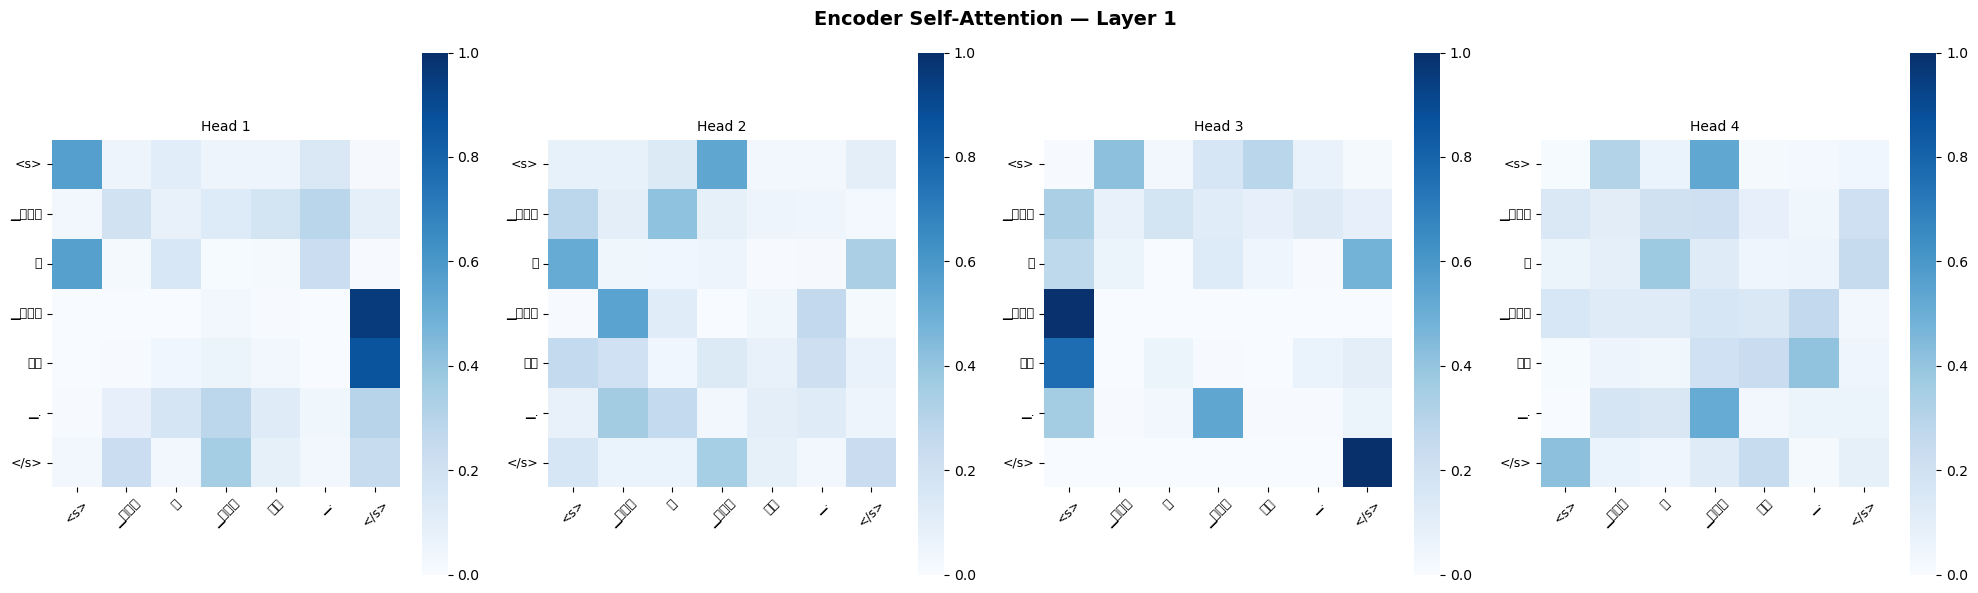

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/c

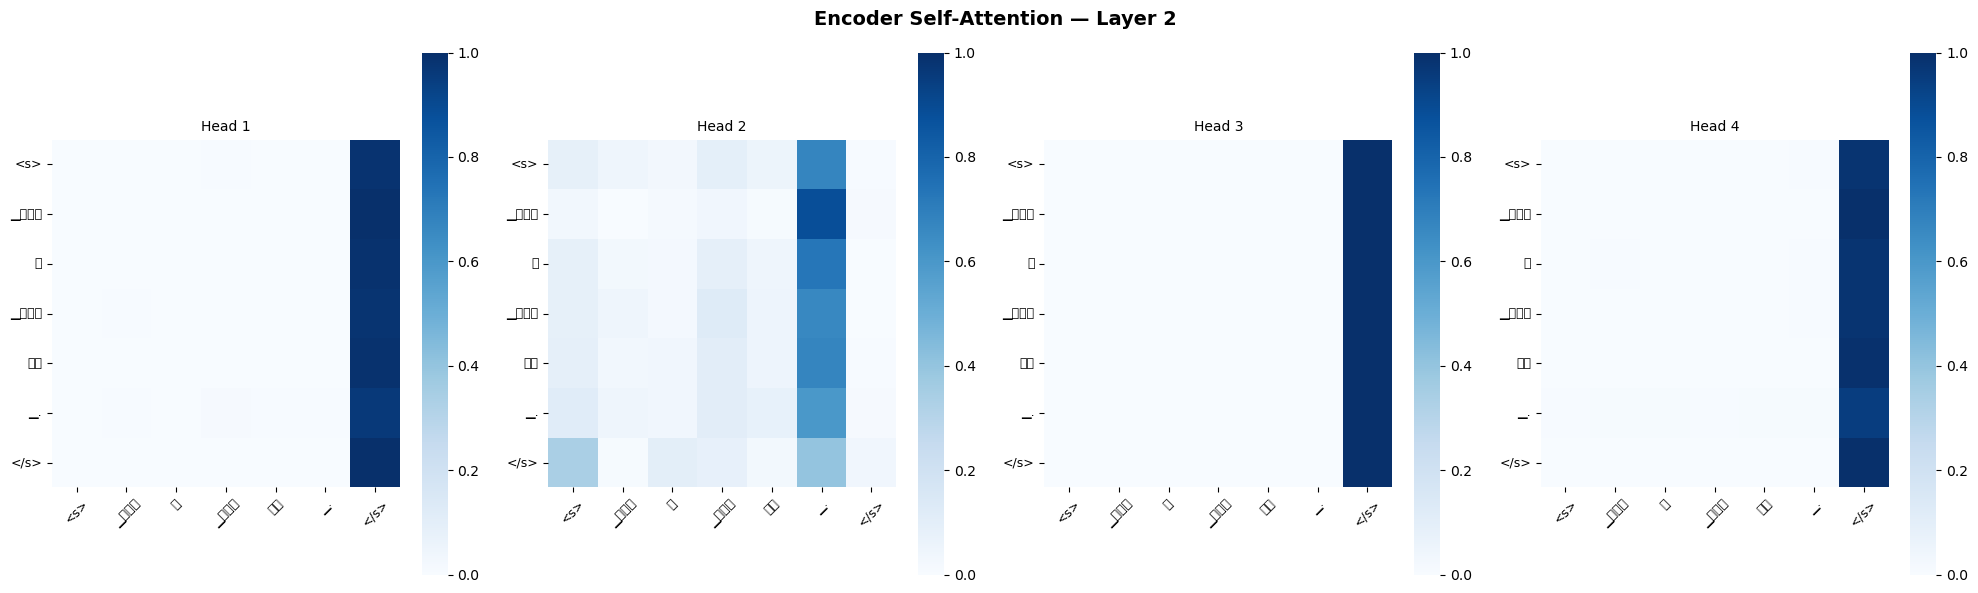

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# fontprop = fm.FontProperties(fname=fontpath, size=9)
# # plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['font.family'] = fontprop.get_name()
# plt.rcParams['axes.unicode_minus'] = False
# sns.set(font=fontprop.get_name())

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    """
    src: 소스 토큰 리스트 (pieces)
    tgt: 타겟 토큰 리스트 (pieces)
    enc_attns:     [n_layers, batch, n_heads, src_len, src_len]
    dec_attns:     [n_layers, batch, n_heads, tgt_len, tgt_len]
    dec_enc_attns: [n_layers, batch, n_heads, tgt_len, src_len]
    """
    try:
        font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' 
        font_prop = fm.FontProperties(fname=font_path, size=14)
        plt.rc('font', family='NanumBarunGothic')
    except:
        # 폰트 경로가 다를 경우 기본 폰트 사용
        plt.rcParams['font.family'] = 'sans-serif'
    
    def draw(data, ax, x_labels="auto", y_labels="auto"):
        # tensor → numpy 변환
        if hasattr(data, 'cpu'):
            data = data.cpu().detach().numpy()

        sns.heatmap(
            data,
            square=True,
            vmin=0.0, vmax=1.0,
            cbar=True,
            ax=ax,
            xticklabels=x_labels,
            yticklabels=y_labels,
            cmap='Blues'
        )
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.tick_params(axis='y', rotation=0,  labelsize=9)

    # n_layers, n_heads를 하드코딩 대신 동적으로 추출
    n_layers = len(enc_attns)
    n_heads  = enc_attns[0].shape[1]  # [batch, n_heads, ...]

    src_len = len(src)
    tgt_len = len(tgt)

    # ─── Encoder Self-Attention ───────────────────────────────
    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads, figsize=(n_heads * 5, 6))
        if n_heads == 1:
            axs = [axs]

        fig.suptitle(f'Encoder Self-Attention — Layer {layer+1}',
                     fontsize=14, fontweight='bold')

        for h in range(n_heads):
            attn = enc_attns[layer][0, h, :src_len, :src_len]
            draw(attn, axs[h], x_labels=src, y_labels=src)
            axs[h].set_title(f'Head {h+1}', fontsize=10)

        plt.tight_layout()
        plt.show()

    # ─── Decoder Self-Attention & Cross-Attention ─────────────
    for layer in range(n_layers):

        # Decoder Self-Attention
        fig, axs = plt.subplots(1, n_heads, figsize=(n_heads * 5, 6))
        if n_heads == 1:
            axs = [axs]

        fig.suptitle(f'Decoder Self-Attention — Layer {layer+1}',
                     fontsize=14, fontweight='bold')

        for h in range(n_heads):
            attn = dec_attns[layer][0, h, :tgt_len, :tgt_len]
            draw(attn, axs[h], x_labels=tgt, y_labels=tgt)
            axs[h].set_title(f'Head {h+1}', fontsize=10)

        plt.tight_layout()
        plt.show()

        # Decoder-Encoder Cross-Attention
        fig, axs = plt.subplots(1, n_heads, figsize=(n_heads * 5, 6))
        if n_heads == 1:
            axs = [axs]

        fig.suptitle(f'Decoder-Encoder Cross-Attention — Layer {layer+1}',
                     fontsize=14, fontweight='bold')

        for h in range(n_heads):
            attn = dec_enc_attns[layer][0, h, :tgt_len, :src_len]
            draw(attn, axs[h], x_labels=src, y_labels=tgt)
            axs[h].set_title(f'Head {h+1}', fontsize=10)

        plt.tight_layout()
        plt.show()


def translate(sentence, model, src_tokenizer, tgt_tokenizer,
              plot_attention=False):

    try:
        font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' 
        font_prop = fm.FontProperties(fname=font_path, size=14)
        plt.rc('font', family='NanumBarunGothic')
    except:
        # 폰트 경로가 다를 경우 기본 폰트 사용
        plt.rcParams['font.family'] = 'sans-serif'
    
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print(f'Input:                {sentence}')
    print(f'Predicted translation: {result}')

    if plot_attention:
        tgt_pieces = tgt_tokenizer.encode_as_pieces(result)

        # pieces, tgt_pieces가 비어있으면 시각화 스킵
        if not pieces or not tgt_pieces:
            print('[시각화 스킵] 번역 결과가 없습니다.')
            return

        visualize_attention(pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)

translate(
    "오바마는 대통령이다.",
    transformer,
    ko_tokenizer,
    en_tokenizer,
    plot_attention=True   
)